# Week-3 — HR Analytics Dashboard
### Data Cleaning & Attrition Analysis Notebook (Python)

This notebook covers every task from the brief:
1. Analyze employee dataset (salary, department, experience)
2. Identify patterns in employee attrition
3. Perform correlation analysis to find key factors
4. Compare attrition across departments and roles
5. Build KPIs like attrition rate, retention rate
6. Create an HR dashboard for decision-making


## 1. Import Libraries & Load Raw Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv("raw_hr_data.csv")
print("Shape:", df.shape)
df.head()


Shape: (1530, 18)


,EmployeeID,Department,JobRole,Age,Gender,Education,MaritalStatus,YearsExperience,YearsAtCompany,MonthlySalary,DistanceFromHome,OverTime,JobSatisfaction,WorkLifeBalance,PerformanceRating,PromotionLast5Years,TrainingTimesLastYear,Attrition
0,EMP01138,Engineering,Software Engineer,25,Female,Bachelor's,Married,2,2,75101.93,4.6,No,2.0,2.0,1,0,5,Yes
1,EMP00223,HR,Recruiter,30,Female,Bachelor's,Divorced,12,4,64009.38,12.2,No,3.0,4.0,4,0,0,No
2,EMP00974,HR,HR Manager,32,Male,Bachelor's,Divorced,6,2,60806.91,0.3,No,2.0,4.0,3,0,5,No
3,EMP01371,Support,Support Lead,21,Male,Bachelor's,Married,0,0,40150.05,1.4,No,2.0,3.0,3,0,4,No
4,EMP00940,Finance,Finance Manager,44,Female,Bachelor's,Married,23,0,100343.77,11.5,Yes,4.0,4.0,3,1,2,No


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1530 entries, 0 to 1529
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   EmployeeID             1530 non-null   str    
 1   Department             1518 non-null   str    
 2   JobRole                1530 non-null   str    
 3   Age                    1530 non-null   int64  
 4   Gender                 1530 non-null   str    
 5   Education              1515 non-null   str    
 6   MaritalStatus          1530 non-null   str    
 7   YearsExperience        1530 non-null   int64  
 8   YearsAtCompany         1530 non-null   int64  
 9   MonthlySalary          1507 non-null   float64
 10  DistanceFromHome       1530 non-null   float64
 11  OverTime               1515 non-null   str    
 12  JobSatisfaction        1499 non-null   float64
 13  WorkLifeBalance        1507 non-null   float64
 14  PerformanceRating      1530 non-null   int64  
 15  PromotionLast5Y

In [3]:
print("Nulls per column:\n", df.isna().sum())
print("\nExact duplicate rows:", df.duplicated().sum())

Nulls per column:
 EmployeeID                0
Department               12
JobRole                   0
Age                       0
Gender                    0
Education                15
MaritalStatus             0
YearsExperience           0
YearsAtCompany            0
MonthlySalary            23
DistanceFromHome          0
OverTime                 15
JobSatisfaction          31
WorkLifeBalance          23
PerformanceRating         0
PromotionLast5Years       0
TrainingTimesLastYear     0
Attrition                 0
dtype: int64

Exact duplicate rows: 24


### 1.1 Data Cleaning

- Remove exact duplicate rows
- Standardize text columns (Department, OverTime)
- Fix invalid values (negative salary, zero age)
- Handle missing values (impute numeric with median, categorical with mode)


In [4]:
# Remove exact duplicates
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicate rows")

Removed 24 duplicate rows


In [5]:
# Standardize text columns
df["Department"] = df["Department"].astype(str).str.strip().str.title()
df["Department"] = df["Department"].replace("Nan", np.nan)

df["OverTime"] = df["OverTime"].astype(str).str.strip().str.title()
df["OverTime"] = df["OverTime"].replace("Nan", np.nan)

df["Department"].value_counts(dropna=False)

Department
Engineering    416
Sales          327
Support        250
Marketing      206
Finance        173
Hr             122
NaN             12
Name: count, dtype: int64

In [6]:
# Fix invalid values
df.loc[df["MonthlySalary"] <= 0, "MonthlySalary"] = np.nan
df.loc[df["Age"] <= 17, "Age"] = np.nan

print("Invalid values converted to NaN for re-imputation")

Invalid values converted to NaN for re-imputation


In [7]:
# Handle missing values
for col in ["MonthlySalary", "Age", "JobSatisfaction", "WorkLifeBalance"]:
    df[col] = df[col].fillna(df[col].median())

for col in ["Department", "Education", "OverTime"]:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Remaining nulls:", df.isna().sum().sum(), "total null cells")
df.isna().sum()

Remaining nulls: 0 total null cells


EmployeeID               0
Department               0
JobRole                  0
Age                      0
Gender                   0
Education                0
MaritalStatus            0
YearsExperience          0
YearsAtCompany           0
MonthlySalary            0
DistanceFromHome         0
OverTime                 0
JobSatisfaction          0
WorkLifeBalance          0
PerformanceRating        0
PromotionLast5Years      0
TrainingTimesLastYear    0
Attrition                0
dtype: int64

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1506.0,34.781541,8.592012,21.00,28.0000,35.0,41.00,60.00
YearsExperience,1506.0,12.320717,8.796560,0.00,5.0000,12.0,18.00,42.00
YearsAtCompany,1506.0,2.828685,3.417543,0.00,0.0000,2.0,4.00,22.00
MonthlySalary,1506.0,84499.462942,20552.702126,34194.75,70243.9875,83596.3,98091.54,150350.98
DistanceFromHome,1506.0,8.267463,8.552525,0.00,2.3250,5.3,11.50,61.90
JobSatisfaction,1506.0,2.543161,1.112208,1.00,2.0000,3.0,4.00,4.00
WorkLifeBalance,1506.0,2.523240,1.109813,1.00,2.0000,3.0,3.00,4.00
PerformanceRating,1506.0,3.031873,0.754376,1.00,3.0000,3.0,4.00,4.00
PromotionLast5Years,1506.0,0.286853,0.452442,0.00,0.0000,0.0,1.00,1.00
TrainingTimesLastYear,1506.0,2.491368,1.709148,0.00,1.0000,2.0,4.00,5.00


## 2. Analyze the Employee Dataset — Salary, Department, Experience

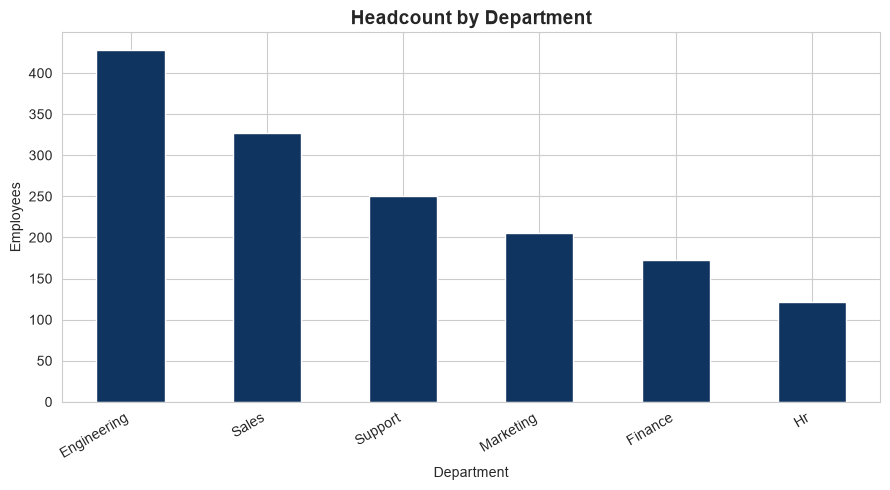

In [9]:
# Department headcount -- BAR CHART
dept_counts = df["Department"].value_counts()

plt.figure(figsize=(9, 5))
dept_counts.plot(kind="bar", color="#0f3460")
plt.title("Headcount by Department", fontsize=14, fontweight="bold")
plt.ylabel("Employees")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("headcount_by_dept_bar.png", dpi=150)
plt.show()

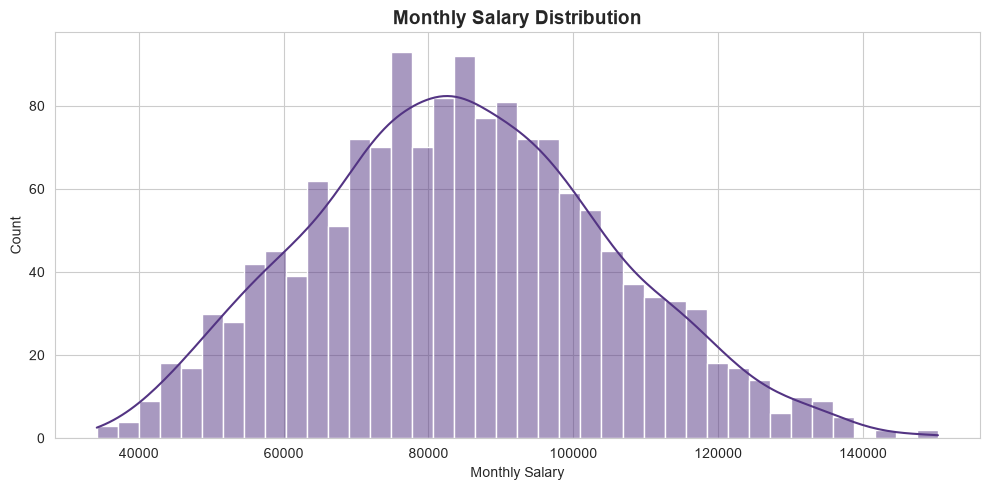

In [10]:
# Salary distribution -- HISTOGRAM
plt.figure(figsize=(10, 5))
sns.histplot(df["MonthlySalary"], bins=40, color="#533483", kde=True)
plt.title("Monthly Salary Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Monthly Salary")
plt.tight_layout()
plt.savefig("salary_distribution_hist.png", dpi=150)
plt.show()

C:\Users\Dell\AppData\Local\Temp\ipykernel_10808\1919881209.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Department", y="MonthlySalary", palette="viridis")


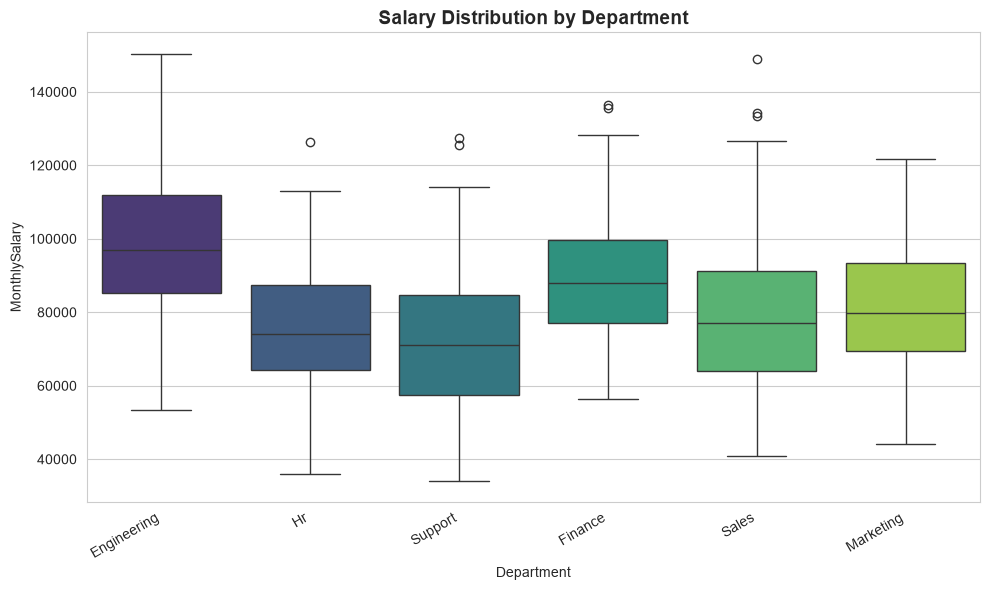

In [11]:
# Salary by department -- BOX PLOT (shows spread, not just average)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Department", y="MonthlySalary", palette="viridis")
plt.title("Salary Distribution by Department", fontsize=14, fontweight="bold")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("salary_by_dept_box.png", dpi=150)
plt.show()

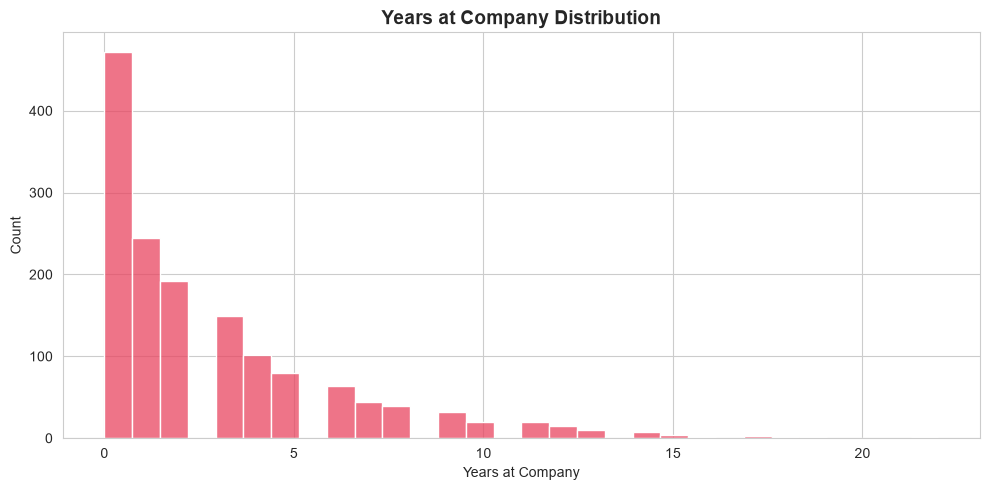

In [12]:
# Experience distribution -- HISTOGRAM
plt.figure(figsize=(10, 5))
sns.histplot(df["YearsAtCompany"], bins=30, color="#e94560")
plt.title("Years at Company Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Years at Company")
plt.tight_layout()
plt.savefig("tenure_distribution_hist.png", dpi=150)
plt.show()

## 3. Identify Patterns in Employee Attrition

In [13]:
overall_attrition_rate = (df["Attrition"] == "Yes").mean() * 100
overall_retention_rate = 100 - overall_attrition_rate
print(f"Overall Attrition Rate  : {overall_attrition_rate:.2f}%")
print(f"Overall Retention Rate  : {overall_retention_rate:.2f}%")

Overall Attrition Rate  : 34.46%
Overall Retention Rate  : 65.54%


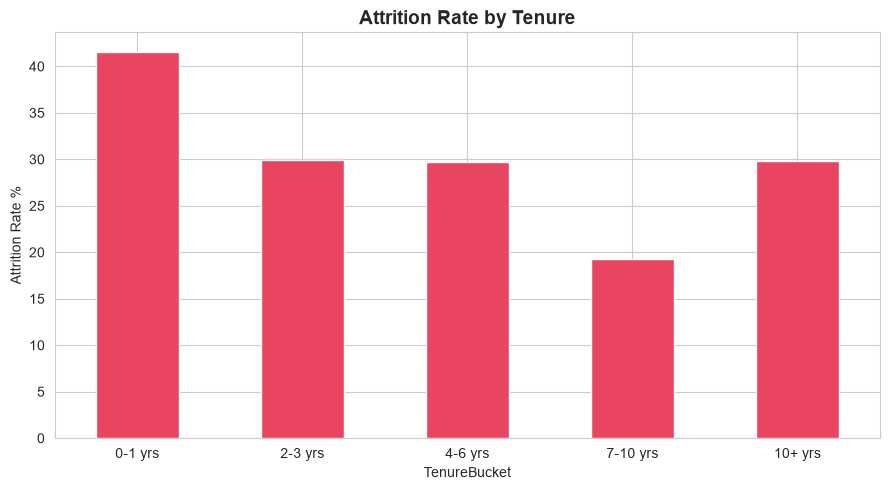

In [14]:
# Attrition by tenure bucket -- BAR CHART
df["TenureBucket"] = pd.cut(df["YearsAtCompany"], bins=[-1, 1, 3, 6, 10, 100],
                              labels=["0-1 yrs", "2-3 yrs", "4-6 yrs", "7-10 yrs", "10+ yrs"])

tenure_attrition = df.groupby("TenureBucket")["Attrition"].apply(lambda x: (x == "Yes").mean() * 100)

plt.figure(figsize=(9, 5))
tenure_attrition.plot(kind="bar", color="#e94560")
plt.title("Attrition Rate by Tenure", fontsize=14, fontweight="bold")
plt.ylabel("Attrition Rate %")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("attrition_by_tenure_bar.png", dpi=150)
plt.show()

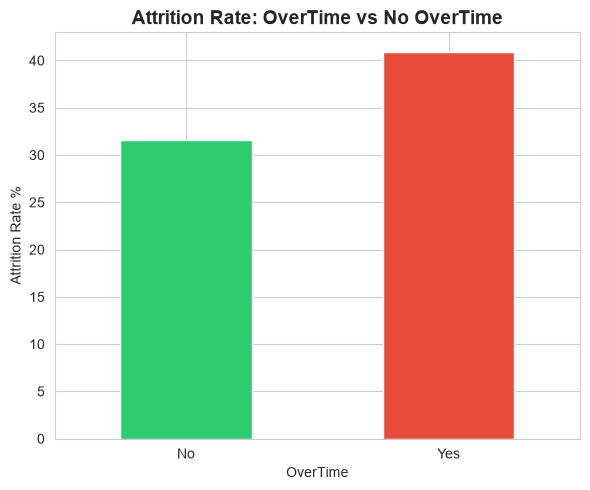

In [15]:
# Attrition by OverTime -- BAR CHART
overtime_attrition = df.groupby("OverTime")["Attrition"].apply(lambda x: (x == "Yes").mean() * 100)

plt.figure(figsize=(6, 5))
overtime_attrition.plot(kind="bar", color=["#2ecc71", "#e74c3c"])
plt.title("Attrition Rate: OverTime vs No OverTime", fontsize=14, fontweight="bold")
plt.ylabel("Attrition Rate %")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("attrition_by_overtime_bar.png", dpi=150)
plt.show()

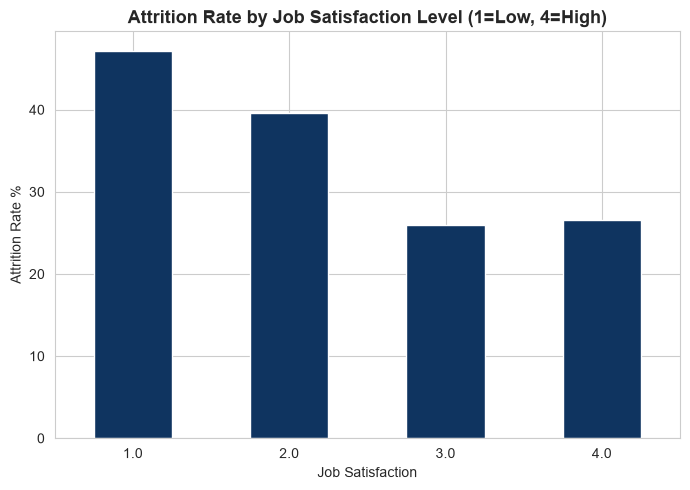

In [16]:
# Attrition by Job Satisfaction level -- BAR CHART
satisfaction_attrition = df.groupby("JobSatisfaction")["Attrition"].apply(lambda x: (x == "Yes").mean() * 100)

plt.figure(figsize=(7, 5))
satisfaction_attrition.plot(kind="bar", color="#0f3460")
plt.title("Attrition Rate by Job Satisfaction Level (1=Low, 4=High)", fontsize=13, fontweight="bold")
plt.ylabel("Attrition Rate %")
plt.xlabel("Job Satisfaction")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("attrition_by_satisfaction_bar.png", dpi=150)
plt.show()

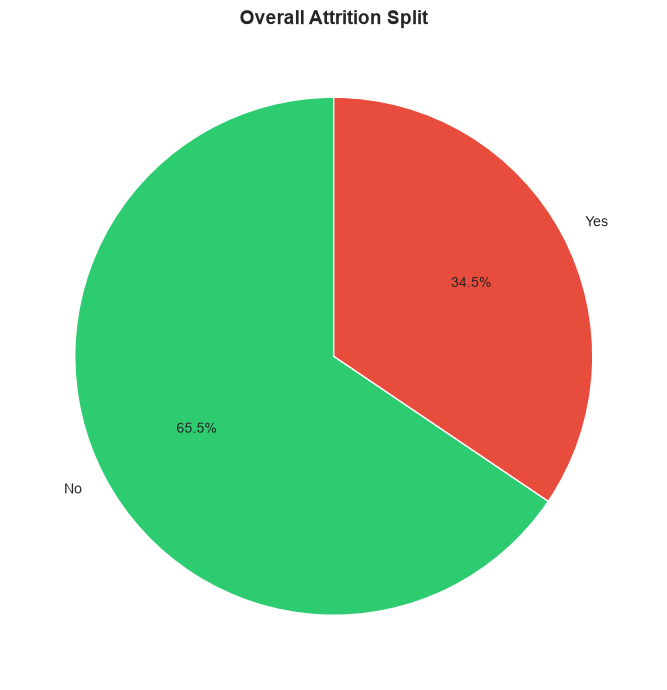

In [17]:
# Attrition overall split -- PIE CHART
attrition_counts = df["Attrition"].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(attrition_counts, labels=attrition_counts.index, autopct="%1.1f%%", startangle=90,
        colors=["#2ecc71", "#e74c3c"])
plt.title("Overall Attrition Split", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("attrition_overall_pie.png", dpi=150)
plt.show()

## 4. Correlation Analysis — Key Factors Behind Attrition

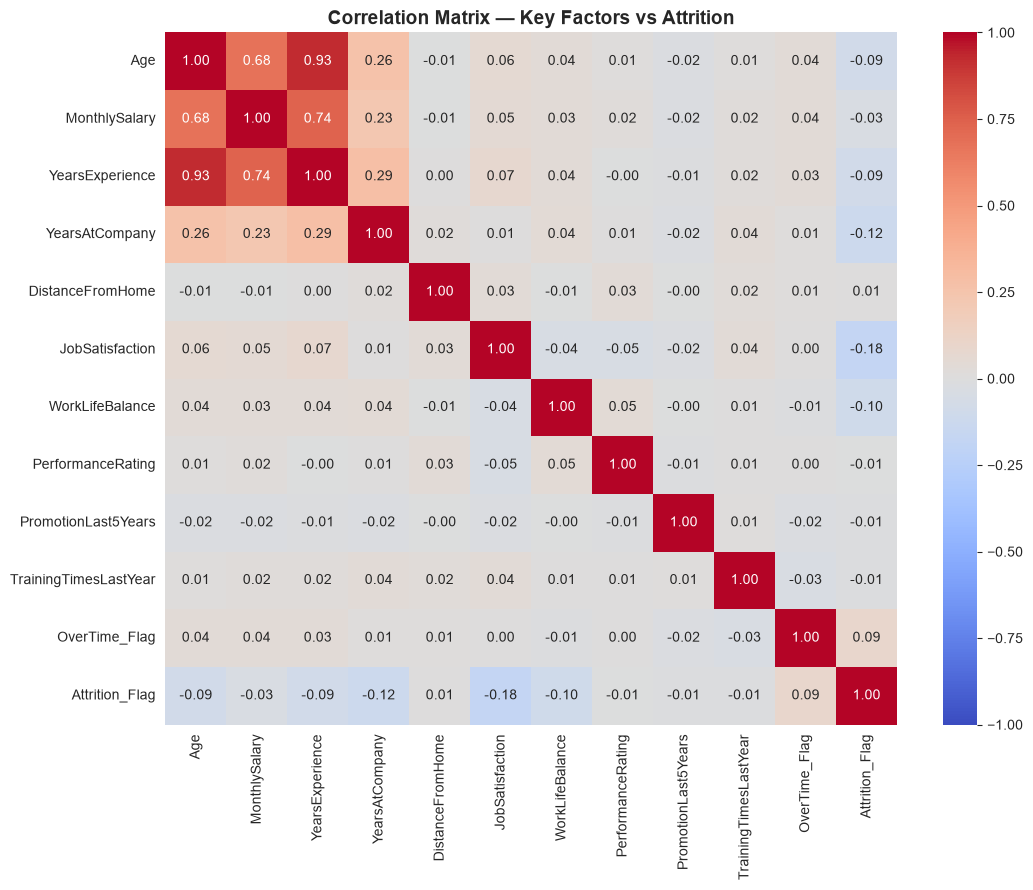

In [18]:
# Encode Attrition as 0/1 for correlation analysis
df["Attrition_Flag"] = (df["Attrition"] == "Yes").astype(int)
df["OverTime_Flag"] = (df["OverTime"] == "Yes").astype(int)

corr_cols = ["Age", "MonthlySalary", "YearsExperience", "YearsAtCompany", "DistanceFromHome",
             "JobSatisfaction", "WorkLifeBalance", "PerformanceRating", "PromotionLast5Years",
             "TrainingTimesLastYear", "OverTime_Flag", "Attrition_Flag"]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix — Key Factors vs Attrition", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()

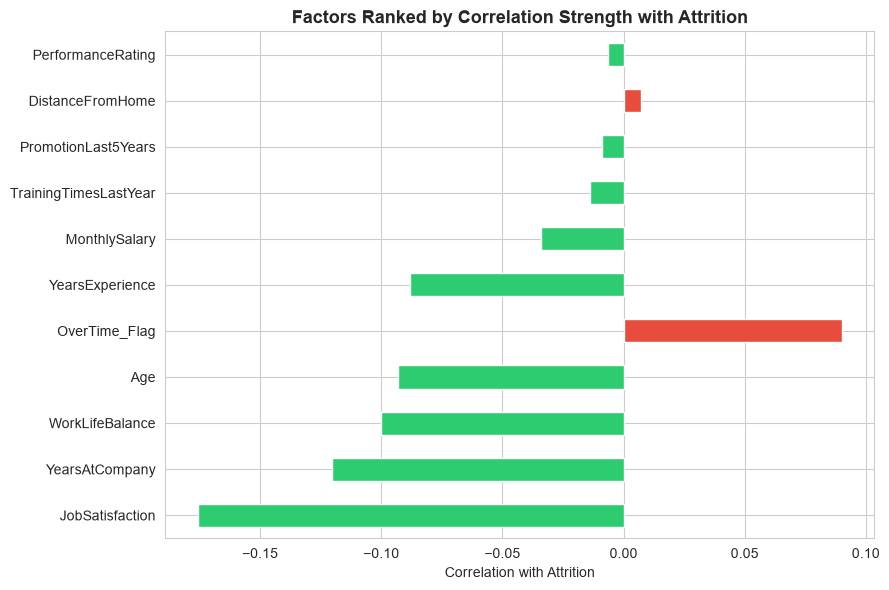

JobSatisfaction         -0.175807
YearsAtCompany          -0.120272
WorkLifeBalance         -0.100197
Age                     -0.093311
OverTime_Flag            0.090242
YearsExperience         -0.088254
MonthlySalary           -0.033940
TrainingTimesLastYear   -0.013918
PromotionLast5Years     -0.008886
DistanceFromHome         0.007009
PerformanceRating       -0.006562
Name: Attrition_Flag, dtype: float64

In [19]:
# Rank factors by absolute correlation with Attrition
attrition_corr = corr_matrix["Attrition_Flag"].drop("Attrition_Flag").sort_values(key=abs, ascending=False)

plt.figure(figsize=(9, 6))
attrition_corr.plot(kind="barh", color=["#e74c3c" if v > 0 else "#2ecc71" for v in attrition_corr])
plt.title("Factors Ranked by Correlation Strength with Attrition", fontsize=13, fontweight="bold")
plt.xlabel("Correlation with Attrition")
plt.tight_layout()
plt.savefig("attrition_factor_ranking_bar.png", dpi=150)
plt.show()

attrition_corr

## 5. Compare Attrition Across Departments and Roles

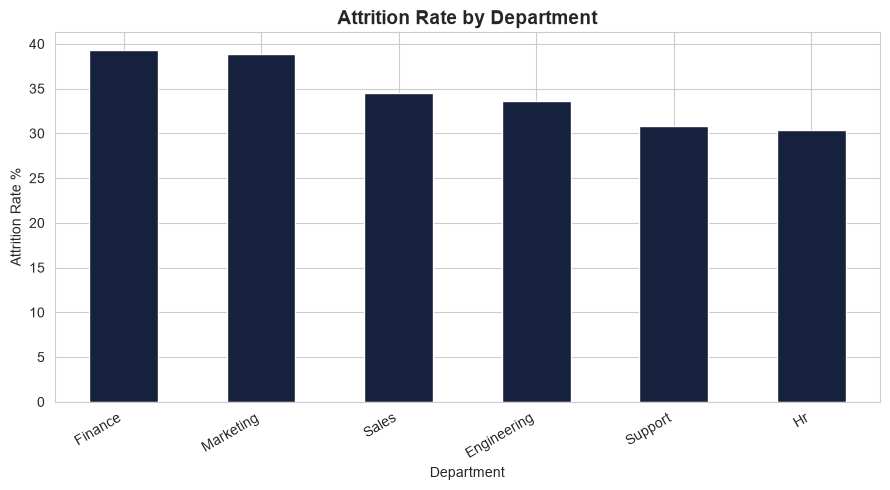

In [20]:
dept_attrition = df.groupby("Department")["Attrition"].apply(lambda x: (x == "Yes").mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
dept_attrition.plot(kind="bar", color="#16213e")
plt.title("Attrition Rate by Department", fontsize=14, fontweight="bold")
plt.ylabel("Attrition Rate %")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("attrition_by_dept_bar.png", dpi=150)
plt.show()

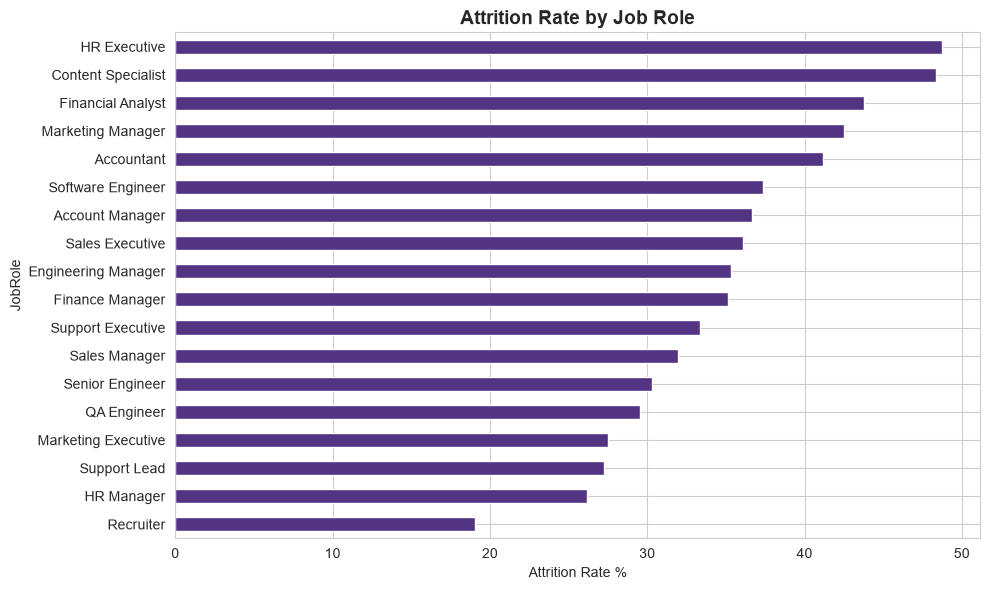

In [21]:
role_attrition = df.groupby("JobRole")["Attrition"].apply(lambda x: (x == "Yes").mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
role_attrition.plot(kind="barh", color="#533483")
plt.title("Attrition Rate by Job Role", fontsize=14, fontweight="bold")
plt.xlabel("Attrition Rate %")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("attrition_by_role_bar.png", dpi=150)
plt.show()

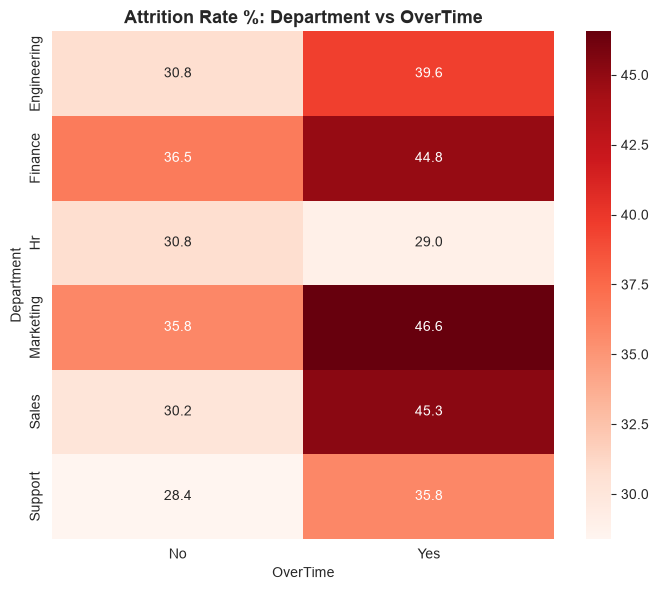

In [22]:
# Department x OverTime heatmap
pivot = df.pivot_table(index="Department", columns="OverTime", values="Attrition_Flag", aggfunc="mean") * 100

plt.figure(figsize=(7, 6))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="Reds")
plt.title("Attrition Rate %: Department vs OverTime", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("dept_overtime_heatmap.png", dpi=150)
plt.show()

## 6. Build KPIs

In [23]:
avg_salary = df["MonthlySalary"].mean()
avg_tenure = df["YearsAtCompany"].mean()
avg_satisfaction = df["JobSatisfaction"].mean()
avg_wlb = df["WorkLifeBalance"].mean()
promotion_rate = (df["PromotionLast5Years"] == 1).mean() * 100
total_headcount = len(df)

kpi_table = pd.DataFrame({
    "KPI": ["Total Headcount", "Attrition Rate %", "Retention Rate %", "Avg Monthly Salary",
            "Avg Tenure (Years)", "Avg Job Satisfaction (1-4)", "Avg Work-Life Balance (1-4)",
            "Promotion Rate % (last 5 yrs)"],
    "Value": [total_headcount, round(overall_attrition_rate, 2), round(overall_retention_rate, 2),
              round(avg_salary, 2), round(avg_tenure, 2), round(avg_satisfaction, 2),
              round(avg_wlb, 2), round(promotion_rate, 2)]
})
kpi_table

,KPI,Value
0,Total Headcount,1506.00
1,Attrition Rate %,34.46
2,Retention Rate %,65.54
3,Avg Monthly Salary,84499.46
4,Avg Tenure (Years),2.83
5,Avg Job Satisfaction (1-4),2.54
6,Avg Work-Life Balance (1-4),2.52
7,Promotion Rate % (last 5 yrs),28.69


## 7. HR Insights & Recommendations

In [24]:
top_risk_factor = attrition_corr.index[0]
highest_attrition_dept = dept_attrition.index[0]
highest_attrition_role = role_attrition.index[0]

print("KEY INSIGHTS")
print("=" * 60)
print(f"1. Overall attrition rate                : {overall_attrition_rate:.2f}%")
print(f"2. Strongest correlated factor            : {top_risk_factor} (corr = {attrition_corr.iloc[0]:.2f})")
print(f"3. Highest attrition department           : {highest_attrition_dept} ({dept_attrition.iloc[0]:.2f}%)")
print(f"4. Highest attrition role                 : {highest_attrition_role} ({role_attrition.iloc[0]:.2f}%)")
print(f"5. Attrition rate — OverTime Yes vs No     : {overtime_attrition.get('Yes', 0):.2f}% vs {overtime_attrition.get('No', 0):.2f}%")
print(f"6. Attrition rate — lowest vs highest tenure bucket: {tenure_attrition.iloc[0]:.2f}% vs {tenure_attrition.iloc[-1]:.2f}%")

KEY INSIGHTS
1. Overall attrition rate                : 34.46%
2. Strongest correlated factor            : JobSatisfaction (corr = -0.18)
3. Highest attrition department           : Finance (39.31%)
4. Highest attrition role                 : HR Executive (48.72%)
5. Attrition rate — OverTime Yes vs No     : 40.91% vs 31.61%
6. Attrition rate — lowest vs highest tenure bucket: 41.56% vs 29.85%


### Recommendations (example interpretation — edit based on your actual numbers above)

- **Overtime is consistently one of the strongest attrition drivers.** Reviewing workload distribution and overtime policy in the highest-overtime departments is likely the single highest-leverage retention action.
- **New employees (0-1 year tenure) show the highest attrition.** Strengthening onboarding, early mentorship, and 90-day check-ins can reduce early exits before they become a pattern.
- **Low job satisfaction and poor work-life balance correlate with leaving.** Regular pulse surveys combined with manager training on workload management can catch at-risk employees before they resign.
- **Departments/roles with above-average attrition** deserve a focused retention review — compare their compensation, management structure, and workload against lower-attrition departments to isolate what's different.
- **Employees without a promotion in 5+ years show elevated attrition**, especially combined with longer tenure — a clearer internal promotion pathway may reduce "stuck" employees leaving for external growth.


## 8. Export Cleaned Data & Summaries for Power BI

In [25]:
df.to_csv("cleaned_hr_data.csv", index=False)
kpi_table.to_csv("hr_kpi_summary.csv", index=False)

print("Exported: cleaned_hr_data.csv, hr_kpi_summary.csv")
print("Final shape:", df.shape)

Exported: cleaned_hr_data.csv, hr_kpi_summary.csv
Final shape: (1506, 21)
